# 1. Phoenix Park GeoJSON

Read in, explore and process the GeoJSON file from https://data.gov.ie/dataset/parks-gardens-and-public-spaces-dcc

In [1]:
# Load packages
import geopandas as gpd

In [12]:
# Read in geosjon file and see what we're working with
parks = gpd.read_file('../data/dcc_parks_strategy2016_park_classification.geojson')
parks.head()

,PRIMARYINDEX,Park_ID,Name,Class,Typology,Location,Astro_Pitches,All_Weather_Pitches,MUGA,Football_5_a_Side,...,GAA,Soccer_Football,Seven_a_Side,Rugby,Hard_Landscape,Committee_Area,Area_mSq,Area_Acre,Multipolygon,geometry
0,1223,484.0,Openspace at Clonshaugh Close,04,Amenity Public Open Spaces,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1874.958,0.463,NaN,"MULTIPOLYGON (((-6.20969 53.40416, -6.2097 53...."
1,188,981.0,Georges Dock,04,Amenity Public Open Spaces,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,yes,NaN,1992.119,0.492,NaN,"MULTIPOLYGON (((-6.24847 53.34942, -6.24846 53..."
2,187,980.0,Georges Dock 2,04,Amenity Public Open Spaces,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,yes,NaN,1145.548,0.283,NaN,"MULTIPOLYGON (((-6.24955 53.34948, -6.2497 53...."
3,186,979.0,Georges Dock 1,04,Amenity Public Open Spaces,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,yes,NaN,193.888,0.048,NaN,"MULTIPOLYGON (((-6.24919 53.34946, -6.2491 53...."
4,185,978.0,Harbour Master Place 1,04,Amenity Public Open Spaces,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,yes,NaN,593.370,0.147,NaN,"MULTIPOLYGON (((-6.24902 53.35107, -6.24919 53..."


In [13]:
# Filter to in clude only Phoenix Park

parks[parks.Name.str.contains('Phoenix')]['Name'].unique()

<StringArray>
['Phoenix Park ']
Length: 1, dtype: str

In [14]:
parks[parks.Name == 'Phoenix Park '].head()

,PRIMARYINDEX,Park_ID,Name,Class,Typology,Location,Astro_Pitches,All_Weather_Pitches,MUGA,Football_5_a_Side,...,GAA,Soccer_Football,Seven_a_Side,Rugby,Hard_Landscape,Committee_Area,Area_mSq,Area_Acre,Multipolygon,geometry
94,1122,755.0,Phoenix Park,1,Flagship Park,Phoenix Park,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,OPW,6799669.317,1680.235,YES,"MULTIPOLYGON (((-6.34132 53.36677, -6.3413 53...."


# 2. Filter to Phoenix Park boundary

In [15]:
phoenix = parks[parks.Name.str.contains('Phoenix')].copy()
phoenix

,PRIMARYINDEX,Park_ID,Name,Class,Typology,Location,Astro_Pitches,All_Weather_Pitches,MUGA,Football_5_a_Side,...,GAA,Soccer_Football,Seven_a_Side,Rugby,Hard_Landscape,Committee_Area,Area_mSq,Area_Acre,Multipolygon,geometry
94,1122,755.0,Phoenix Park,1,Flagship Park,Phoenix Park,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,OPW,6799669.317,1680.235,YES,"MULTIPOLYGON (((-6.34132 53.36677, -6.3413 53...."


Ensure this shows what we want, i.e. the boundaries of the Phoenx Park

In [23]:
phoenix.geometry.geom_type.value_counts()

MultiPolygon    1
Name: count, dtype: int64

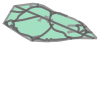

In [24]:
phoenix.geometry.iloc[0]

Which coordinate system are we working with? Need to make sure the GeoJSON coordinates are compatible with the Sentinel-2 raster, otherwise we need to reproject the coordinates onto what the sentinel-2 data uses.

In [28]:
phoenix.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

WGS 84 / EPSG:4326 - means that the coordinates are in long/lat in degrees.  

We'll likely use Sentinel-2 raster in metres (EPSG:32629 (UTM Zone 29N)) because Sentinel-2's spatial resolution is in metres (e.g. 10m pixels).  

No need to reproject the park boundary just yet - we can explicitly choose a suitable CRS/resolution when we load Sentinel-2 data and then transform the park geometry to match it.

# 3. Get a sample Sentinel-2 observation


Just download one image for now to inspect it.  
Use a STAC catalog to find and access one Sentinel-2 scene for the Phoenix Park.  
We'll use Microsoft Planetary Computer's STAC API.

Level-2A applies atmospheric correction to estimate the reflectance at the Earth's surface. It also provides useful quality information, including a Scene Classification Layer (SCL) that identifies things such as clouds, cloud shadows, vegetation, water and snow

In [30]:
import pystac_client
import planetary_computer

In [ ]:
# Connect to a catalogue containing metadata about available observations (metadata first, raster data later)
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1'
    )

In [37]:
#Explore the catalogue
collection = catalog.get_collection("sentinel-2-l2a")

print(collection.id)
print(collection.title)

sentinel-2-l2a
Sentinel-2 Level-2A


Search for July observations.  

For now, just use a rectangle bounding box for a rough search to make sure everything works ok.

In [ ]:
# Get the bounding box
phoenix.total_bounds
# [min_x, min_y, max_x, max_y] (in long/lat)
# [west, south, east, north]

array([-6.35630402, 53.34629501, -6.29497606, 53.3712433 ])

Run the STAC search

In [ ]:
search = catalog.search(
    collections = ['sentinel-2-l2a'],
    bbox = phoenix.total_bounds,
    datetime='2026-07-01/2026-07-31'
)

# note that using the bbox argument here does not restrict the results to the park bounds rectangle, rather it returns all scenes that overlap this area 
# (which are likely much larger, they just contain the park)

In [69]:
items = list(search.items())

In [70]:
len(items)

18

There are 18 images in July 2026 within our bounding box. Let's take a look at how cloudy these images are (because we can't use very cloudy images)

In [74]:
for item in items:
    print(
        item.datetime.date(),
        item.properties['eo:cloud_cover']
        )

2026-07-30 34.713548
2026-07-28 71.167737
2026-07-25 99.747229
2026-07-25 99.660331
2026-07-23 97.773719
2026-07-22 50.016135
2026-07-20 80.262679
2026-07-18 29.242787
2026-07-15 19.680642
2026-07-15 24.00787
2026-07-13 34.744766
2026-07-12 2.876604
2026-07-10 28.218237
2026-07-08 0.55251
2026-07-05 99.999958
2026-07-05 99.619186
2026-07-03 91.259724
2026-07-02 93.254745


For the actual search, we'll want to filter out cloudy scenes, but for now let's include everything.

# 4. Inspect a suitable scene

Let's look at a relatively cloud-free July scene and inspect it's available assets

In [75]:
item = items[13]

for key, asset in item.assets.items():
    print(key, "->", asset.title)

AOT -> Aerosol optical thickness (AOT)
B01 -> Band 1 - Coastal aerosol - 60m
B02 -> Band 2 - Blue - 10m
B03 -> Band 3 - Green - 10m
B04 -> Band 4 - Red - 10m
B05 -> Band 5 - Vegetation red edge 1 - 20m
B06 -> Band 6 - Vegetation red edge 2 - 20m
B07 -> Band 7 - Vegetation red edge 3 - 20m
B08 -> Band 8 - NIR - 10m
B09 -> Band 9 - Water vapor - 60m
B11 -> Band 11 - SWIR (1.6) - 20m
B12 -> Band 12 - SWIR (2.2) - 20m
B8A -> Band 8A - Vegetation red edge 4 - 20m
SCL -> Scene classfication map (SCL)
WVP -> Water vapour (WVP)
visual -> True color image
safe-manifest -> SAFE manifest
granule-metadata -> Granule metadata
inspire-metadata -> INSPIRE metadata
product-metadata -> Product metadata
datastrip-metadata -> Datastrip metadata
tilejson -> TileJSON with default rendering
rendered_preview -> Rendered preview


We are interested in B04 (red band) and B08 (near infrared band) because NDVI is calculated as (NIR - red)/(NIR + red).
Also SCL will help us to distinguish between vegatation and clouds or other non-useful pixels.

# 5. Load the actual raster data

Use odc-stac to turn the STAC item into an xarray dataset.  

First, let's double check the crs for the Sentinel-2 data:

In [76]:
item.properties['proj:code']

'EPSG:32629'

Load the raster for our selected scene using EPSG:32629 as the target crs and a 10m resolution, to match B04 and B08.

In [ ]:
from odc.stac import load

In [ ]:
ds = load(
    [item],
    bands=['B04', 'B08', 'SCL'],
    crs='EPSG:32629',
    resolution=10
)

Aborting load due to failure while reading: https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/29/U/PV/2026/07/08/S2B_MSIL2A_20260708T114349_N0512_R123_T29UPV_20260708T152442.SAFE/GRANULE/L2A_T29UPV_A048769_20260708T114435/IMG_DATA/R10m/T29UPV_20260708T114349_B04_10m.tif:1


RasterioIOError: HTTP response code: 409

We need to sign the STAC asset URLs before we can download the rasters

In [79]:
item = planetary_computer.sign(item)

In [ ]:
print(item.assets["B04"].href)
#should give a URL with something like '...?sig=...'

https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/29/U/PV/2026/07/08/S2B_MSIL2A_20260708T114349_N0512_R123_T29UPV_20260708T152442.SAFE/GRANULE/L2A_T29UPV_A048769_20260708T114435/IMG_DATA/R10m/T29UPV_20260708T114349_B04_10m.tif?st=2026-08-15T09%3A53%3A44Z&se=2026-08-16T10%3A38%3A44Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-08-16T09%3A47%3A18Z&ske=2026-08-23T09%3A47%3A18Z&sks=b&skv=2025-07-05&sig=M7DqhVzbEsYd5Y7PGRy3FuU13KMZ8RgAl9544sXE0gE%3D


Reload the raster data with the signed URL

In [83]:
ds = load(
    [item],
    bands=['B04', 'B08', 'SCL'],
    crs='EPSG:32629',
    resolution=10
)

In [84]:
ds

<xarray.Dataset> Size: 1GB
Dimensions:      (y: 10980, x: 10980, time: 1)
Coordinates:
  * y            (y) float64 88kB 6e+06 6e+06 6e+06 ... 5.89e+06 5.89e+06
  * x            (x) float64 88kB 6e+05 6e+05 6e+05 ... 7.098e+05 7.098e+05
  * time         (time) datetime64[us] 8B 2026-07-08T11:43:49.024000
    spatial_ref  int32 4B 32629
Data variables:
    B04          (time, y, x) float32 482MB 1.558e+03 1.32e+03 ... 1.079e+03
    B08          (time, y, x) float32 482MB 5.355e+03 5.077e+03 ... 1.046e+03
    SCL          (time, y, x) float32 482MB 4.0 4.0 4.0 4.0 ... 6.0 6.0 6.0 6.0

Looks good, but that's a lot of pixels to download (10,980*10,980 per Band!) for a small project.  

Now we know everything is working, let's restrict the raster to only the park boundaries.  

Next step, reproject the park polygon from EPSG:4326 (degrees) to EPSG:32629 (metres).

In [86]:
park_utm = phoenix.to_crs('EPSG:32629')

In [87]:
park_utm.crs

<Projected CRS: EPSG:32629>
Name: WGS 84 / UTM zone 29N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 12°W and 6°W, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Côte D'Ivoire (Ivory Coast). Faroe Islands. Guinea. Ireland. Jan Mayen. Liberia, Mali. Mauritania. Morocco. Portugal. Sierra Leone. Spain. United Kingdom (UK). Western Sahara.
- bounds: (-12.01, 0.0, -6.0, 84.01)
Coordinate Operation:
- name: UTM zone 29N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [88]:
park_utm.total_bounds

array([ 675929.7255781 , 5914124.74473145,  680050.29649826,
       5916874.43343763])

# 6. Crop the raster to the park

First crop the raster to the rectangle given by the total bounds of the park

In [89]:
xmin, ymin, xmax, ymax = park_utm.total_bounds

Note that y values run north to south (i.e. they decrease as we move down the raster), e.g.:

In [90]:
ds.y.values[0], ds.y.values[-1]

(np.float64(5999995.0), np.float64(5890205.0))

Now crop the raster to the park bounds rectangle

In [91]:
park_bbox = ds.sel(
    x = slice(xmin, xmax),
    y = slice(ymax, ymin) #note slice from max to min for y
)

In [92]:
park_bbox

<xarray.Dataset> Size: 1MB
Dimensions:      (y: 275, x: 412, time: 1)
Coordinates:
  * y            (y) float64 2kB 5.917e+06 5.917e+06 ... 5.914e+06 5.914e+06
  * x            (x) float64 3kB 6.759e+05 6.759e+05 ... 6.8e+05 6.8e+05
  * time         (time) datetime64[us] 8B 2026-07-08T11:43:49.024000
    spatial_ref  int32 4B 32629
Data variables:
    B04          (time, y, x) float32 453kB 1.567e+03 1.807e+03 ... 2.199e+03
    B08          (time, y, x) float32 453kB 3.897e+03 3.196e+03 ... 3.127e+03
    SCL          (time, y, x) float32 453kB 5.0 5.0 5.0 4.0 ... 5.0 5.0 5.0 5.0

In [93]:
print(ds.sizes)
print(park_bbox.sizes)

Frozen({'y': 10980, 'x': 10980, 'time': 1})
Frozen({'y': 275, 'x': 412, 'time': 1})


# 7. Mask the raster to the park boundary

In [95]:
import rioxarray

In [ ]:
park_bbox = park_bbox.rio.write_crs("EPSG:32629") #tell rioxarray which crs the coordinates in park_bbox are in

In [97]:
park_bbox.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 29N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32629"]]')

In [98]:
park_bbox.rio.crs.to_epsg()

32629

# 8. Apply Phoenix Park polygon mask

In [99]:
park_masked = park_bbox.rio.clip(
    park_utm.geometry, #this is the shape of the mask
    park_utm.crs, # this is the crs the geometry is expressed in
    drop=False #keep existing rectangular raster but turn pixels outside polygon to NaN
)

In [100]:
park_masked

<xarray.Dataset> Size: 1MB
Dimensions:      (y: 275, x: 412, time: 1)
Coordinates:
  * y            (y) float64 2kB 5.917e+06 5.917e+06 ... 5.914e+06 5.914e+06
  * x            (x) float64 3kB 6.759e+05 6.759e+05 ... 6.8e+05 6.8e+05
  * time         (time) datetime64[us] 8B 2026-07-08T11:43:49.024000
    spatial_ref  int64 8B 0
Data variables:
    B04          (time, y, x) float32 453kB nan nan nan nan ... nan nan nan nan
    B08          (time, y, x) float32 453kB nan nan nan nan ... nan nan nan nan
    SCL          (time, y, x) float32 453kB nan nan nan nan ... nan nan nan nan

In [101]:
park_masked.sizes

Frozen({'y': 275, 'x': 412, 'time': 1})

In [102]:
park_masked.B04.isnull().sum()

<xarray.DataArray 'B04' ()> Size: 8B
array(45343)
Coordinates:
    spatial_ref  int64 8B 0

We have 275*412 (= 113,300) pixels in the cropped rectangle, and 45,343 of them are now NaN because they fall outside the park polygon.  
So we are left with about 67,957 inside the park boudary.

# 9. Calculate NDVI

NDVI = (NIR - Red)/(NIR + Red)  
where NIR = B08 and Red = B04

In [103]:
ndvi = (
    (park_masked.B08 - park_masked.B04)
    / (park_masked.B08 + park_masked.B04)
)

In [104]:
ndvi

<xarray.DataArray (time: 1, y: 275, x: 412)> Size: 453kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(1, 275, 412), dtype=float32)
Coordinates:
  * time         (time) datetime64[us] 8B 2026-07-08T11:43:49.024000
  * y            (y) float64 2kB 5.917e+06 5.917e+06 ... 5.914e+06 5.914e+06
  * x            (x) float64 3kB 6.759e+05 6.759e+05 ... 6.8e+05 6.8e+05
    spatial_ref  int64 8B 0

In [105]:
ndvi.min().item(), ndvi.max().item()

(-0.02729257568717003, 0.7146949768066406)

NDVI can range from -1 to +1, with values around 0 typical of things like bare soil, built surfaces, water. Positive values indicate vegation. Values around 0.7 are consistent with fairly dense, healthy vegetation, makes sense for Phoenix Park in July.

# 10. Use Scene Classification Layer (SCL) to create a quality mask

We don't want to use all pixels for our vegetation analysis - some might be cloud or water or build areas, for example.

In [106]:
import numpy as np

In [107]:
np.unique(park_masked.SCL.values)

array([ 4.,  5.,  7., nan], dtype=float32)

SCL codes 4, 5, 7:  

4 = Vegetation  
5 = Not vegetated  
7 = Unclassified  

We only need to keep pixels with SCL values of 4 for our analysis

In [108]:
vegetation_mask = park_masked.SCL==4

In [109]:
vegetation_mask.sum()

<xarray.DataArray 'SCL' ()> Size: 8B
array(65885)
Coordinates:
    spatial_ref  int64 8B 0

Apply the vegetation mask to NDVI

In [110]:
ndvi_veg = ndvi.where(vegetation_mask)

In [111]:
ndvi_veg.min().item(), ndvi_veg.max().item()

(-0.008482563309371471, 0.7146949768066406)

In [112]:
ndvi_veg.isnull().sum().item()

47415

# 11. Calculate one park-level value of NDVI

In [113]:
mean_ndvi = ndvi_veg.mean().item()

mean_ndvi

0.5580050945281982

Plot the NDVI to sanity check - lots of things can be hiding behind that single mean NDVI value!

Matplotlib is building the font cache; this may take a moment.


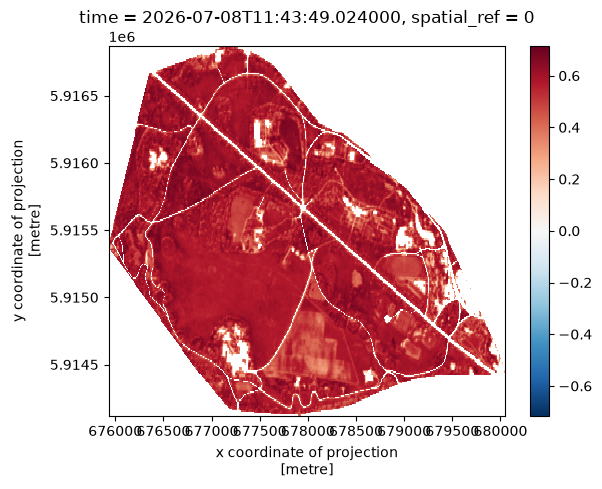

In [115]:
ndvi_veg.squeeze().plot()